# From the project page to the code: a gentle MNIST guide

On the [project page](https://panjiashu.github.io/feature-information-dynamics/#dynamics), the MNIST demo turns two
denoising losses into a picture of **when digit identity becomes visible**. This
notebook walks through the implementation of its four plots:

**Denoising loss → MMSE gap → Feature information density → Accumulated class information.**

We will first look at one digit, then build each curve with a few lines of NumPy.
You need only familiar Python, an average, and a squared error to follow the code;
the I-MMSE identity is the mathematical bridge supplied by the paper.

This guide covers the page's **class-information demonstration**. The later
frequency-band and representation-comparison figures are separate experiments.

## Where the denoiser comes from

We trained a small shared U-Net from random initialization on 55,000 MNIST
training images. It learns to predict the clean image from Gaussian-noised
inputs, sometimes with the class label and sometimes with that label hidden.
Training uses a weighted squared reconstruction loss. A separate 5,000-image
validation set selects the checkpoint with the lowest average denoising loss;
the selected weights are an exponential moving average of the training weights.

The 100,000-update run took **31 minutes 24 seconds on one A100-SXM4-40GB**.
To start with the concepts rather than wait for training, this guide loads that
selected checkpoint. It is **8.55 MB (8.16 MiB)** and includes the model weights
and their configuration. It was trained for this example, with no external
classifier or feature model. Training code and a command are linked at the end.

## Before you begin

Use the whole repository: the notebook download alone does not include its model
or measured data. From the repository root, install the notebook dependencies:

```bash
python -m pip install -e ".[mnist,notebook]"
jupyter lab mnist_information_concepts.ipynb
```

The saved figures are already readable. Running all cells loads our teaching
checkpoint and the supplied, hash-checked full-test measurements, redraws the
curves, and reruns the small image examples. MNIST is downloaded if needed.
It does not retrain the network. From-scratch training is described at the end.

## Choose the image you want to follow

`DIGIT` selects a class; `EXAMPLE` selects an image within that class (starting at
zero). As with the webpage's selector, this changes the **images only**. The curves
summarize all 10,000 test images, across all ten digit classes and two noise draws.
There is one population class-information curve, not a separate curve for each digit.

In [1]:
DIGIT = 3
EXAMPLE = 0

### Load the model and data

Images have 784 pixels, scaled to [-1, 1]. We load a shared U-Net trained from
scratch for this example. Expand the setup cell if you want to see the checkpoint
and dataset loading; the conceptual code begins just below it.

In [2]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from feature_information_dynamics.mnist_data import load_mnist
from feature_information_dynamics.mnist_calibrated import SharedDenoiser
from feature_information_dynamics.noise import stable_noise
from feature_information_dynamics.bundle import sha256, load_bundle

ROOT = Path.cwd().resolve()
ASSETS = ROOT / "examples" / "mnist_class"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(4)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
asset = json.loads((ASSETS / "checkpoint.json").read_text())
checkpoint = ASSETS / "selected.pt"
if sha256(checkpoint) != asset["sha256"]: raise ValueError("Tutorial checkpoint checksum mismatch")
state = torch.load(checkpoint, map_location="cpu", weights_only=True)
model = SharedDenoiser(state["config"]["channels"]).to(device)
model.load_state_dict(state["model"])
model.eval()
arrays, _ = load_mnist(ROOT / "data" / "mnist", download=True)
images = arrays["t10k-images-idx3-ubyte.gz"]
labels = arrays["t10k-labels-idx1-ubyte.gz"]

if not isinstance(DIGIT, int) or not 0 <= DIGIT <= 9:
    raise ValueError("DIGIT must be an integer from 0 to 9")
positions = np.flatnonzero(labels == DIGIT)
if not isinstance(EXAMPLE, int) or not 0 <= EXAMPLE < len(positions):
    raise ValueError("EXAMPLE must index an image in the selected class")

errors, measured_metadata, measured_samples = load_bundle(ASSETS / "measurements")
assert measured_metadata["checkpoint_sha256"] == sha256(checkpoint)
assert [s["sample_id"] for s in measured_samples] == [f"test:{i}" for i in range(len(images))]
assert [s["class_id"] for s in measured_samples] == labels.tolist()
grid = np.asarray(measured_metadata["log10_snr"])
seeds = measured_metadata["noise"]["seeds"]
print(f"Loaded measured errors with axes (mode, SNR, noise, image): {errors.shape}")

Loaded measured errors with axes (mode, SNR, noise, image): (2, 33, 2, 10000)


## Meet the two denoising predictions

The page writes the noisy observation as $X_\gamma=\sqrt\gamma X+N$. Our network
uses $X_t=tX+(1-t)N$, with $\gamma=(t/(1-t))^2$. Dividing $X_t$ by $1-t$ gives
$X_\gamma$, so these are equivalent views of the same observation. The network
always predicts the **clean image**, not the noise.

At a chosen SNR, we call the **same model twice**. `False` replaces the supplied
label by a null label inside the model; `True` uses the digit label. Passing `y` to
the first call therefore does not reveal the class. There is no guidance mixing.

In [3]:
x = torch.from_numpy(images[positions[EXAMPLE]:positions[EXAMPLE]+1]).to(device)
y = torch.tensor([DIGIT], device=device)
noise = torch.randn((1, 784), generator=torch.Generator().manual_seed(20261006)).to(device)
log_snr = -1.0

t = torch.full((1, 1), 1 / (1 + 10**(-log_snr / 2)), device=device)
noisy = t * x + (1 - t) * noise
with torch.no_grad():
    without_label = model(noisy, t, y, False)
    with_label = model(noisy, t, y, True)

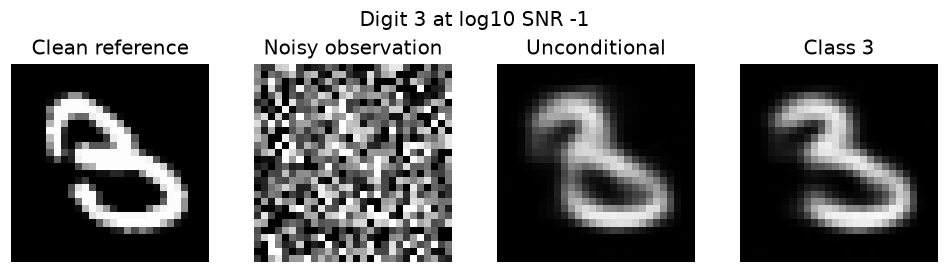

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(9, 2.5))
for ax, image, title in zip(axes, [x, noisy, without_label, with_label],
        ["Clean reference", "Noisy observation", "Unconditional", f"Class {DIGIT}"]):
    ax.imshow(image.detach().cpu().numpy().reshape(28, 28), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(title); ax.axis("off")
fig.suptitle(f"Digit {DIGIT} at log10 SNR {log_snr:g}")
fig.tight_layout(); plt.show()

The class-conditioned prediction has less ambiguity about identity because it
receives the label. These learned predictions approximate conditional means;
they need not be optimal. Like the page's slider frames, they are predictions at
fixed noise levels, **not steps from a reverse-diffusion sampling trajectory**.

One image makes the comparison concrete. The next plots ask whether the label
helps **on average**, using the full test set.

## 1. Denoising loss (x-pred loss)

The first webpage plot measures how far each prediction is from the clean image.
For one image, the code is simply:

```python
squared_error = (prediction - clean_image).double().square().sum(dim=1)
```

We **sum over 784 pixels**, then average over images and noise draws. Using a
per-pixel average here would change the information scale by a factor of 784.
The theoretical minimum of this average loss is MMSE. Our measured denoising loss
is an MMSE estimate, not an assertion that the minimum has been reached.

The supplied measurements store one squared-error sum for every prediction.
Their axes are `(mode, SNR, noise draw, image)`; mode 0 hides the label and mode 1
uses it. Loading these real errors lets us focus on the calculation rather than
wait for a full inference run.

In [5]:
# Keep mode and SNR; average over noise draws and test images.
losses = errors.astype(np.float64).mean(axis=(2, 3))
without_label_loss, with_label_loss = losses

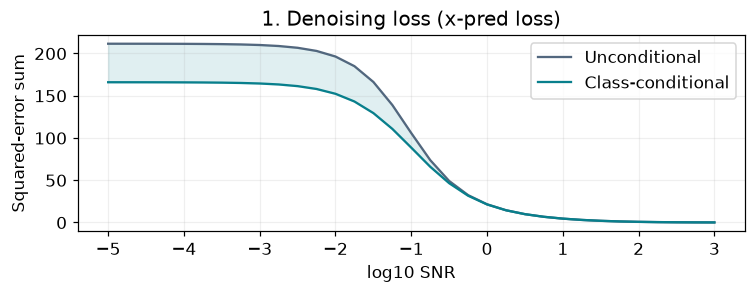

In [6]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(grid, without_label_loss, color="#52677e", label="Unconditional")
ax.plot(grid, with_label_loss, color="#087f8c", label="Class-conditional")
ax.fill_between(grid, with_label_loss, without_label_loss, color="#087f8c", alpha=.12)
ax.set(xlabel="log10 SNR", ylabel="Squared-error sum", title="1. Denoising loss (x-pred loss)")
ax.legend(); ax.grid(alpha=.2); fig.tight_layout(); plt.show()

**Read the plot:** both losses fall as the observation becomes clearer. Their
separation is the reconstruction benefit of knowing the class. Both modes were
measured on exactly the same clean images and noise, so we can subtract them.

## 2. MMSE gap

The second webpage plot makes that separation explicit. In the ideal identity,
it is $m_\varnothing-m_Y$. In our implementation it is the **difference of the two
measured losses**:

In [7]:
gap = without_label_loss - with_label_loss

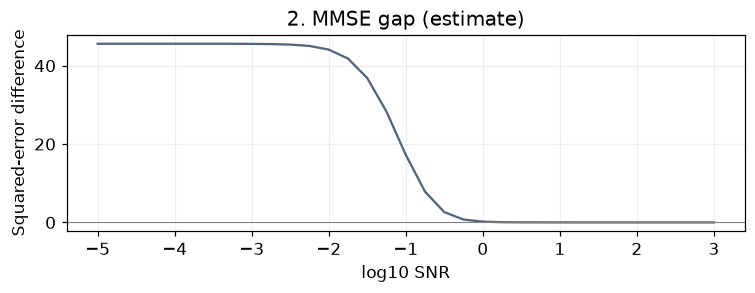

In [8]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(grid, gap, color="#52677e")
ax.axhline(0, color="gray", linewidth=.7)
ax.set(xlabel="log10 SNR", ylabel="Squared-error difference", title="2. MMSE gap (estimate)")
ax.grid(alpha=.2); fig.tight_layout(); plt.show()

**Read the plot:** a larger gap means the label reduces more reconstruction
error at that noise level. It is not yet information density: the next step
converts reconstruction benefit into a rate of information gain. The signed gap
is kept as measured; learned denoisers do not guarantee a nonnegative gap.

## 3. Feature information density

The page defines information density as the rate at which the noisy observation
reveals the feature along log-SNR. I-MMSE gives

$$\frac{d}{d\ln\gamma}I(Y;X_\gamma)
=\frac{\gamma}{2}(m_\varnothing-m_Y).$$

We implement the estimate by multiplying the measured gap by $\gamma/2$.
Here `grid` stores $\log_{10}\gamma$, so $\gamma$ is `10.0**grid`.

True information density is nonnegative. Neural-denoiser fitting error (and
finite-sample measurement error) can produce negative estimates. **Both this
guide and the webpage clip those estimates to zero for display.** We keep the
raw signed density separately for the diagnostic at the end; clipping is a
display convention, not proof that the model has recovered the true information.

In [9]:
density = 0.5 * 10.0**grid * gap          # Raw signed neural estimate.
density_display = np.maximum(density, 0)  # Displayed on the webpage and here.

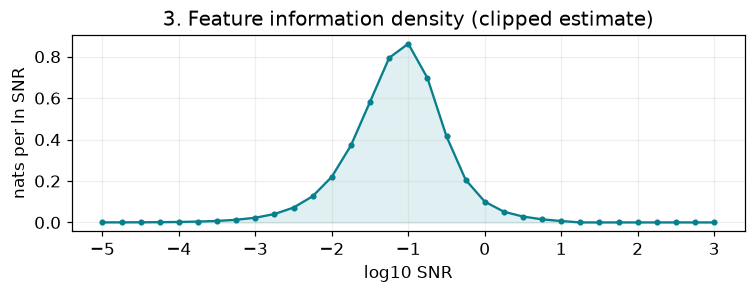

In [10]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(grid, density_display, "o-", markersize=3, color="#087f8c")
ax.fill_between(grid, 0, density_display, color="#087f8c", alpha=.12)
ax.set(xlabel="log10 SNR", ylabel="nats per ln SNR", title="3. Feature information density (clipped estimate)")
ax.grid(alpha=.2); fig.tight_layout(); plt.show()

**Read the plot:** the peak locates where estimated class information enters
most rapidly. The horizontal axis is log10 SNR; the density is still per unit
**natural-log SNR**. That distinction determines the conversion in the integral.

## 4. Accumulated class information

The fourth webpage plot adds up the displayed density from the left edge of the
measured range to the current SNR. We use trapezoids between adjacent grid points.
Because $d\ln\gamma=\ln(10)\,d\log_{10}\gamma$, the area needs `np.log(10)`:

In [11]:
increments = 0.5 * (density_display[:-1] + density_display[1:])
increments *= np.diff(grid) * np.log(10)
positive_cumulative = np.r_[0., np.cumsum(increments)]

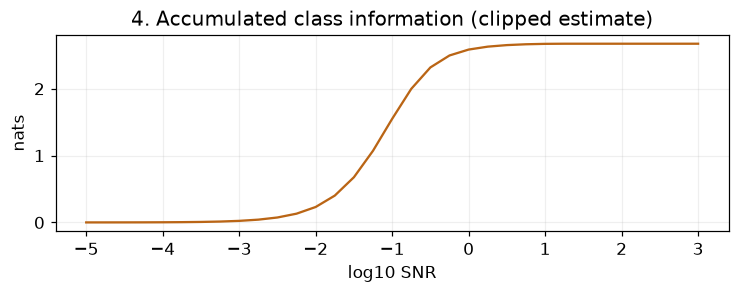

In [12]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(grid, positive_cumulative, color="#ba6515")
ax.set(xlabel="log10 SNR", ylabel="nats", title="4. Accumulated class information (clipped estimate)")
ax.grid(alpha=.2); fig.tight_layout(); plt.show()

**Read the plot:** the slope is largest near the density peak. This is a clipped,
finite-range estimate over log10 SNR [-5, 3], in nats. Starting the curve at zero
means “accumulated since -5”; it does not claim there is no information at -5.
Its endpoint is not automatically the full class entropy.

## A check on the estimator

The webpage displays the clipped integral. For a separate accuracy diagnostic,
we integrate the **raw signed density**, so negative fitting-error estimates
remain visible in the numerical result.

For the MNIST class-label feature, the full-range ideal integral approaches label
entropy $H(Y)$, about $\ln 10$ nats. Our finite SNR range, learned predictions,
finite measurement sample and quadrature can all introduce discrepancies.
Comparing the raw estimate with entropy is a useful check, not a certification
of Bayes MMSE at each SNR.

In [13]:
cumulative = np.r_[0., np.cumsum(.5 * (density[1:] + density[:-1]) * np.diff(grid) * np.log(10))]
integral = float(cumulative[-1])
p = np.bincount(labels, minlength=10) / len(labels)
entropy = float(-np.sum(p * np.log(p)))
relative_error = abs(integral - entropy) / entropy
print(f"Raw signed finite-range integral: {integral:.3f} nats")
print(f"Class entropy reference:         {entropy:.3f} nats")
print(f"Relative integral discrepancy:   {relative_error:.1%}")

result = {"estimate_nats": integral, "reference_nats": entropy,
          "relative_error": relative_error, "passed": bool(relative_error <= .2),
          "sample_count": len(images), "noise_repeat_count": len(seeds),
          "checkpoint_sha256": sha256(checkpoint), "log10_snr": grid.tolist()}
output = ROOT / "runs" / "mnist_quickstart"
output.mkdir(parents=True, exist_ok=True)
(output / "result.json").write_text(json.dumps(result, indent=2) + "\n")

Raw signed finite-range integral: 2.626 nats
Class entropy reference:         2.301 nats
Relative integral discrepancy:   14.1%


636

## Further implementation

For the general chain and Shapley calculations, see
[analysis.py](src/feature_information_dynamics/analysis.py). The
[bundle format](docs/bundle_format.md) explains how paired errors are stored;
the [four-representation protocol](docs/unified_main_results.md) describes the
larger experiments and their current reproduction status.

This notebook implements MNIST class information; the spectral and
representation comparisons require their own measurements.

## Training the denoiser

The supplied shared U-Net was trained from scratch on 55,000 MNIST images,
with 5,000 held-out validation images selecting the checkpoint. Its fixed
100,000-update run took **31 minutes 24 seconds on one A100-SXM4-40GB**.
The complete test measurement then took about **57 seconds on that GPU**.
CPU training timing has not been measured.

Training therefore stays outside the default reading path. To run it yourself,
use the [training implementation](src/feature_information_dynamics/mnist_calibrated.py)
and [full training configuration](configs/mnist_concepts_full.json):

```bash
feature-information mnist-shared-train --config configs/mnist_concepts_full.json --data data/mnist --output runs/my_mnist_denoiser --device cuda --download
```

This writes a new run with its selected weights. The model uses one shared
U-Net, with a zero null-label embedding for the class-hidden mode. The
[independent checkpoint evaluation tool](tools/verify_shared_checkpoint.py)
shows how to measure denoising losses from selected weights. Training and
measurement evidence is recorded in [validation.md](docs/validation.md).